In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/ShreyaSaha102/Amazon_project/refs/heads/main/amazon_sales_dataset.csv")

In [ ]:
df.head()

,Order ID,Order Date,Customer ID,Customer Name,Region,Product Category,Product Name,Quantity Sold,Unit Price,Discount (%),Salesperson,Payment Method,Order Status,Total Sales,Profit Margin
0,576ca8db-ad1a-4aa8-9c3a-89102555f200,1/1/2019,48aa940a-5cb5-4103-8d89-19c10fd26aaf,Stephanie Garcia,South America,Home & Kitchen,Speak,9,484.46,21.33,Johnny Marshall,Debit Card,Returned,3430.12,1193.53
1,b7154d7e-f369-4a81-80b1-d36b23cc0420,1/1/2019,8de3545c-78e6-4962-ace5-02e37fe1ce91,Jacob Morales,South America,Books,If,10,179.28,6.43,Bradley Howe,Gift Card,Pending,1677.52,583.70
2,b2852522-fbaa-43fa-b165-bd10e0035591,1/2/2019,6ac41f61-acf6-4e46-8b70-ad00ce01c9d0,John Carroll,North America,Sports,Big,6,185.34,1.57,Johnny Marshall,Amazon Pay,Completed,1094.58,380.86
3,f14eae78-235f-4283-a2cc-6433fd861c14,1/4/2019,04bb6a6a-a62a-4e79-a038-68758f215ccc,Allison Ramirez,Asia,Home & Kitchen,Serious,5,40.98,4.21,Roger Brown,PayPal,Completed,196.27,68.29
4,c3fcb6f0-a399-47eb-8903-2a354425ea75,1/4/2019,2267ce03-37ba-446a-b279-17ecee550c6e,James Thompson,North America,Toys,Operation,10,459.39,20.50,Kristen Ramos,PayPal,Cancelled,3652.15,1270.78


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          5000 non-null   object 
 1   Order Date        5000 non-null   object 
 2   Customer ID       5000 non-null   object 
 3   Customer Name     5000 non-null   object 
 4   Region            5000 non-null   object 
 5   Product Category  5000 non-null   object 
 6   Product Name      4999 non-null   object 
 7   Quantity Sold     5000 non-null   int64  
 8   Unit Price        5000 non-null   float64
 9   Discount (%)      5000 non-null   float64
 10  Salesperson       5000 non-null   object 
 11  Payment Method    5000 non-null   object 
 12  Order Status      5000 non-null   object 
 13  Total Sales       5000 non-null   float64
 14  Profit Margin     5000 non-null   float64
dtypes: float64(4), int64(1), object(10)
memory usage: 586.1+ KB


In [ ]:
df.describe()

,Quantity Sold,Unit Price,Discount (%),Total Sales,Profit Margin
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.518800,255.161728,14.899920,1187.145384,413.072520
std,2.896088,143.167691,8.705621,988.464586,343.940683
min,1.000000,5.160000,0.000000,4.610000,1.600000
25%,3.000000,130.112500,7.237500,370.127500,128.787500
50%,6.000000,257.080000,14.870000,907.955000,315.930000
75%,8.000000,379.710000,22.442500,1762.252500,613.180000
max,10.000000,499.910000,29.990000,4911.920000,1709.120000


In [ ]:
df.isnull().sum()

Order ID            0
Order Date          0
Customer ID         0
Customer Name       0
Region              0
Product Category    0
Product Name        1
Quantity Sold       0
Unit Price          0
Discount (%)        0
Salesperson         0
Payment Method      0
Order Status        0
Total Sales         0
Profit Margin       0
dtype: int64

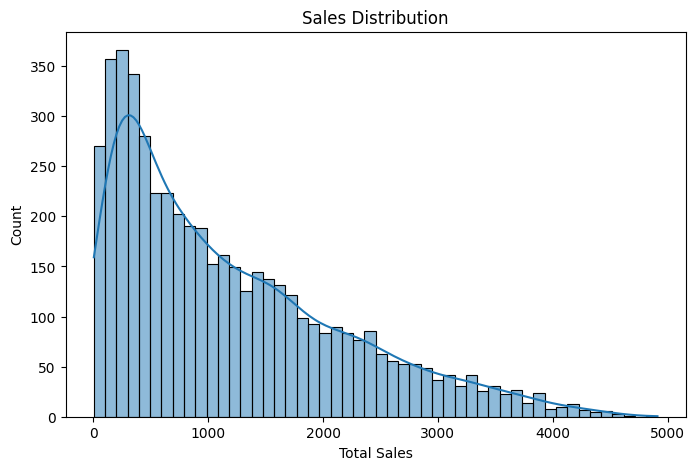

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_3504\403663390.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Total Sales', data=df, estimator=np.sum, ci=None)


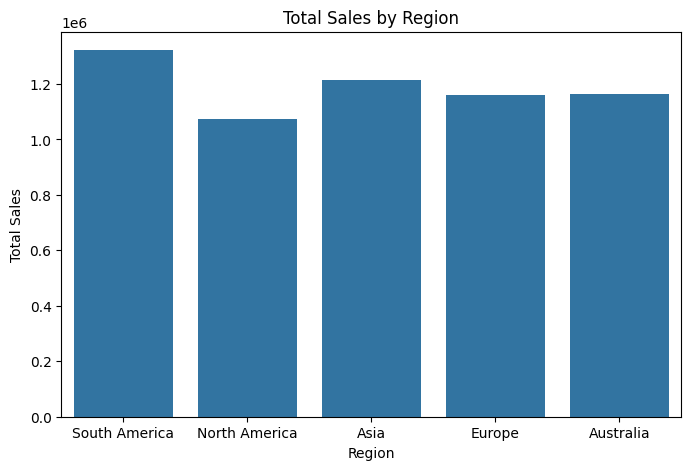

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Total Sales', data=df, estimator=np.sum, ci=None)
plt.title("Total Sales by Region")
plt.show()

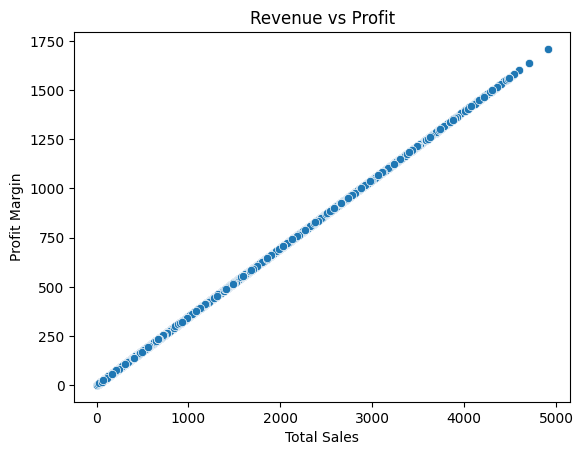

In [ ]:
sns.scatterplot(x='Total Sales', y='Profit Margin', data=df)
plt.title("Revenue vs Profit")
plt.show()

#sns.heatmap(df[['Total Cost','Total Revenue','Total Profit']].corr(), annot=True, cmap="coolwarm")
#plt.title("Correlation Heatmap")
#plt.show()


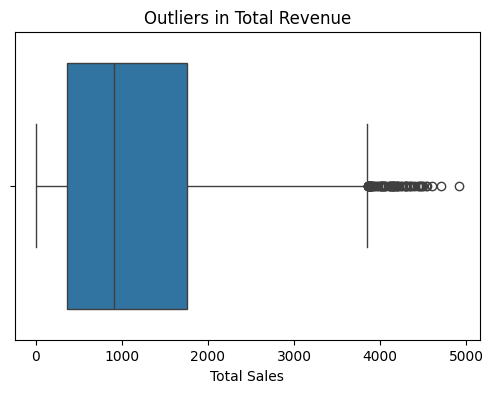

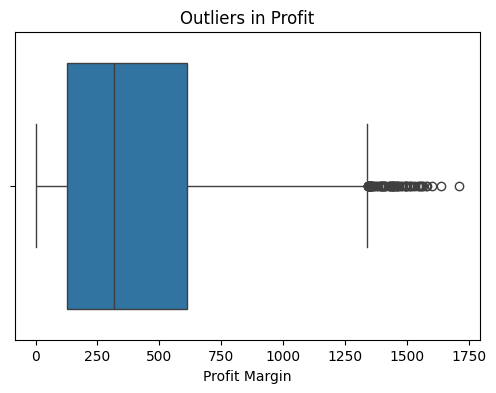

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots for numerical columns
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Total Sales'])
plt.title("Outliers in Total Revenue")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Profit Margin'])
plt.title("Outliers in Profit")
plt.show()


In [ ]:
df = df.groupby('Customer ID').agg({
    'Total Sales': 'sum',
    'Profit Margin': 'sum',
    'Quantity Sold': 'sum',
    'Discount (%)': 'mean',
    'Unit Price': 'mean'
}).reset_index()

In [ ]:
data = df[['Quantity Sold', 'Unit Price', 'Discount (%)', 'Total Sales', 'Profit Margin']]


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])


In [ ]:
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(pca_df)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_df)

pca_df['Cluster'] = clusters
df['Cluster'] = clusters  # add cluster label back to original data


In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set2', s=60)
plt.title('Customer Segments using K-Means + PCA')
plt.show()


In [ ]:
cluster_summary = df.groupby('Cluster')[['Total Sales', 'Profit Margin', 'Quantity Sold']].mean()
print(cluster_summary)


In [ ]:
def prepare_dates(df, date_cols=['Order Date', 'Ship Date']):
    df = df.copy()
    for c in date_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

In [ ]:
#aggregating to customer level

def aggregate_customer(df, id_col=None):
    """
    If id_col is None: try to find 'Customer ID' or 'Customer', else fallback to 'Country', else 'Order ID'.
    """
    df = df.copy()
    # find id column
    if id_col is None:
        for candidate in ['Customer ID', 'Customer', 'CustomerID', 'Client', 'ClientID']:
            if candidate in df.columns:
                id_col = candidate
                break
    if id_col is None:
        if 'Country' in df.columns:
            id_col = 'Country'   # fallback (coarser)
            print("Warning: No customer id found. Falling back to 'Country' for grouping.")
        elif 'Order ID' in df.columns:
            id_col = 'Order ID'
            print("Warning: No customer id or country found. Using 'Order ID' as grouping.")
        else:
            raise ValueError("No suitable id column found for grouping. Add a Customer ID column.")

    # make sure date column exists
    if 'Order Date' not in df.columns:
        raise ValueError("Order Date column required for recency calculation.")

    # reference date for recency: one day after last order in dataset
    ref_date = df['Order Date'].max() + pd.Timedelta(days=1)

    # frequency: number of distinct orders (if Order ID exists) else number of rows
    if 'Order ID' in df.columns:
        freq = df.groupby(id_col)['Order ID'].nunique().rename('frequency')
    else:
        freq = df.groupby(id_col).size().rename('frequency')

    last_order = df.groupby(id_col)['Order Date'].max().rename('last_order_date')
    first_order = df.groupby(id_col)['Order Date'].min().rename('first_order_date')
    recency = (ref_date - last_order).dt.days.rename('recency_days')  # smaller = more recent

    # monetary: total revenue; if not present use Total Profit or compute Units Sold * Unit Price
    if 'Total Revenue' in df.columns:
        monetary = df.groupby(id_col)['Total Revenue'].sum().rename('monetary_revenue')
    elif 'Total Profit' in df.columns:
        monetary = df.groupby(id_col)['Total Profit'].sum().rename('monetary_profit')
    elif {'Units Sold','Unit Price'}.issubset(df.columns):
        monetary = (df['Units Sold'] * df['Unit Price']).groupby(df[id_col]).sum().rename('monetary_est')
    else:
        raise ValueError("No revenue-like column found (Total Revenue/Total Profit/Units Sold+Unit Price).")

    total_units = df.groupby(id_col)['Units Sold'].sum().rename('total_units') if 'Units Sold' in df.columns else None
    total_profit = df.groupby(id_col)['Total Profit'].sum().rename('total_profit') if 'Total Profit' in df.columns else None

    # Combine into one dataframe
    pieces = [freq, last_order, first_order, recency, monetary]
    if total_units is not None: pieces.append(total_units)
    if total_profit is not None: pieces.append(total_profit)

    agg = pd.concat(pieces, axis=1)
    agg = agg.reset_index().set_index(id_col)

    # derived features
    agg['avg_order_value'] = agg[monetary.name] / agg['frequency']
    if total_units is not None:
        agg['avg_units_per_order'] = agg['total_units'] / agg['frequency']
    if total_profit is not None:
        agg['avg_profit_per_order'] = agg['total_profit'] / agg['frequency']
        # profit margin safely
        agg['profit_margin'] = agg['total_profit'] / agg[monetary.name].replace({0:np.nan})

    # fill or clip infinities
    agg = agg.replace([np.inf, -np.inf], np.nan).fillna(0)
    return agg, id_col


In [ ]:
#scaling
def transform_and_scale(df_features, features_to_log=None, scaler=None):
    df = df_features.copy()
    if features_to_log is None:
        # typical skewed RFM features
        features_to_log = [c for c in ['frequency', 'monetary_revenue', 'monetary_profit', 'avg_order_value', 'total_units'] if c in df.columns]
    for c in features_to_log:
        if c in df.columns:
            df['log1p_' + c] = np.log1p(df[c])
    # choose numeric columns to feed to clustering
    # prefer log versions for skewed ones
    chosen = []
    prefer_map = {
        'monetary_revenue': 'log1p_monetary_revenue',
        'monetary_profit': 'log1p_monetary_profit',
        'frequency': 'log1p_frequency'
    }
    for c in ['recency_days', 'avg_order_value', 'avg_units_per_order', 'avg_profit_per_order', 'profit_margin']:
        if c in df.columns:
            chosen.append(c)
    # add preferred log columns if they exist
    for raw, logcol in prefer_map.items():
        if logcol in df.columns:
            chosen.insert(0, logcol)  # prefer logs earlier
        elif raw in df.columns:
            chosen.insert(0, raw)
    # ensure uniqueness
    chosen = [c for i,c in enumerate(chosen) if c not in chosen[:i]]

    X = df[chosen].fillna(0).copy()
    if scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)
    return X, X_scaled, chosen, scaler

In [ ]:
# choose k by elbow and silhouette
def evaluate_k(X_scaled, k_min=2, k_max=10, use_mini_batch=False):
    inertias = []
    silhouettes = []
    K_range = range(k_min, k_max+1)
    for k in K_range:
        if use_mini_batch:
            km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10, batch_size=1000)
        else:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        if k > 1:
            silhouettes.append(silhouette_score(X_scaled, labels))
        else:
            silhouettes.append(np.nan)
    return K_range, inertias, silhouettes

def plot_elbow_silhouette(K_range, inertias, silhouettes):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    ax[0].plot(list(K_range), inertias, marker='o')
    ax[0].set_title("Elbow: Inertia vs k")
    ax[0].set_xlabel("k")
    ax[0].set_ylabel("Inertia")
    ax[1].plot(list(K_range), silhouettes, marker='o')
    ax[1].set_title("Silhouette Score vs k")
    ax[1].set_xlabel("k")
    ax[1].set_ylabel("Silhouette Score")
    plt.tight_layout()
    plt.show()


In [ ]:
#fit k means
def fit_kmeans(X_scaled, n_clusters):
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    return km, labels

def cluster_profile(agg_df, labels, chosen_features):
    agg = agg_df.copy()
    agg['cluster'] = labels
    profile = agg.groupby('cluster')[chosen_features].agg(['count','mean','median']).T
    # also summary stats per cluster (counts)
    counts = agg['cluster'].value_counts().sort_index().rename('cluster_count')
    return agg, profile, counts

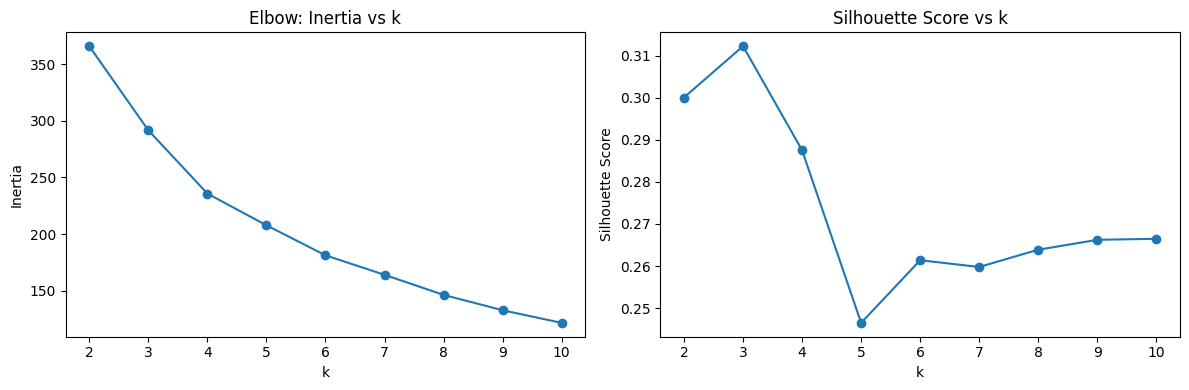

Auto-picked k by silhouette: 3


In [ ]:
df = prepare_dates(df, date_cols=['Order Date', 'Ship Date'])

# 2) aggregate
agg_df, used_id = aggregate_customer(df, id_col=None)  # will auto-detect customer column or fallback

# 3) transform and scale
X_df, X_scaled, chosen_features, scaler = transform_and_scale(agg_df)

# 4) choose k
K_range, inertias, silhouettes = evaluate_k(X_scaled, k_min=2, k_max=10)
plot_elbow_silhouette(K_range, inertias, silhouettes)

# 5) choose a k manually from plots (or pick best silhouette)
best_k = int(np.nanargmax(silhouettes) + K_range[0])  # best by silhouette (quick auto-pick)
print("Auto-picked k by silhouette:", best_k)

In [ ]:
#fitting model
km_model, labels = fit_kmeans(X_scaled, n_clusters=best_k)

In [ ]:
agg_with_clusters, profile, counts = cluster_profile(agg_df, labels, chosen_features)
print("Cluster counts:\n", counts)
print("\nCluster profile (mean/median):\n", profile.round(2))

KeyError: "Columns not found: 'log1p_monetary_revenue', 'log1p_frequency'"

Dataset Shape: (5000, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          5000 non-null   object 
 1   Order Date        5000 non-null   object 
 2   Customer ID       5000 non-null   object 
 3   Customer Name     5000 non-null   object 
 4   Region            5000 non-null   object 
 5   Product Category  5000 non-null   object 
 6   Product Name      4999 non-null   object 
 7   Quantity Sold     5000 non-null   int64  
 8   Unit Price        5000 non-null   float64
 9   Discount (%)      5000 non-null   float64
 10  Salesperson       5000 non-null   object 
 11  Payment Method    5000 non-null   object 
 12  Order Status      5000 non-null   object 
 13  Total Sales       5000 non-null   float64
 14  Profit Margin     5000 non-null   float64
dtypes: float64(4), int64(1), object(10)
memor

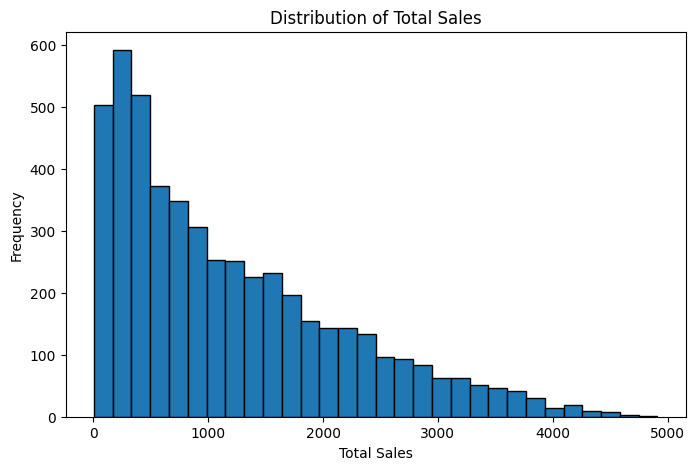

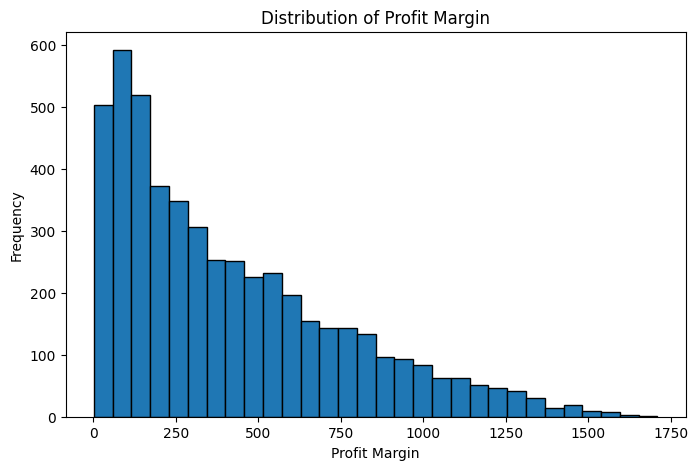


Total Sales by Region:
Region
South America    1322175.34
Asia             1213830.23
Australia        1164771.22
Europe           1160480.98
North America    1073059.87
Name: Total Sales, dtype: float64


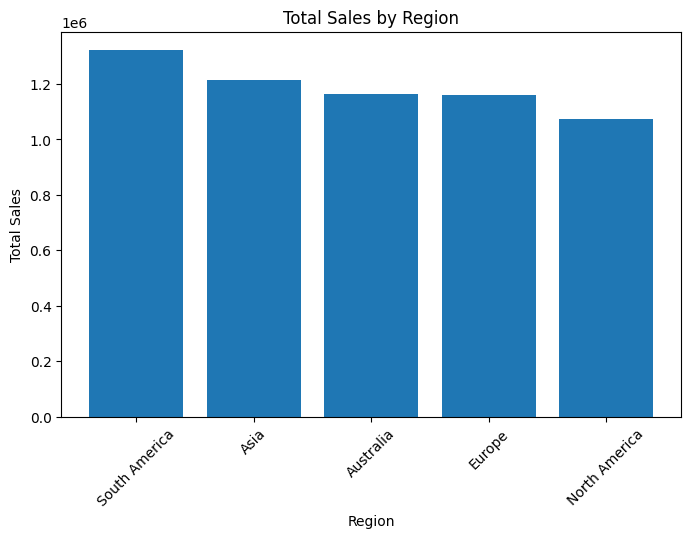

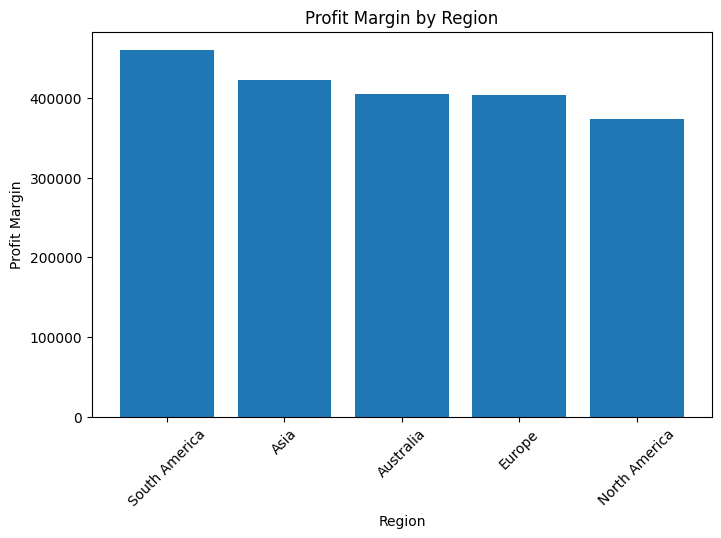


Total Sales by Product Category:
Product Category
Sports            894838.14
Clothing          874698.53
Toys              864701.55
Electronics       854348.56
Home & Kitchen    837059.82
Books             814614.05
Beauty            794056.99
Name: Total Sales, dtype: float64


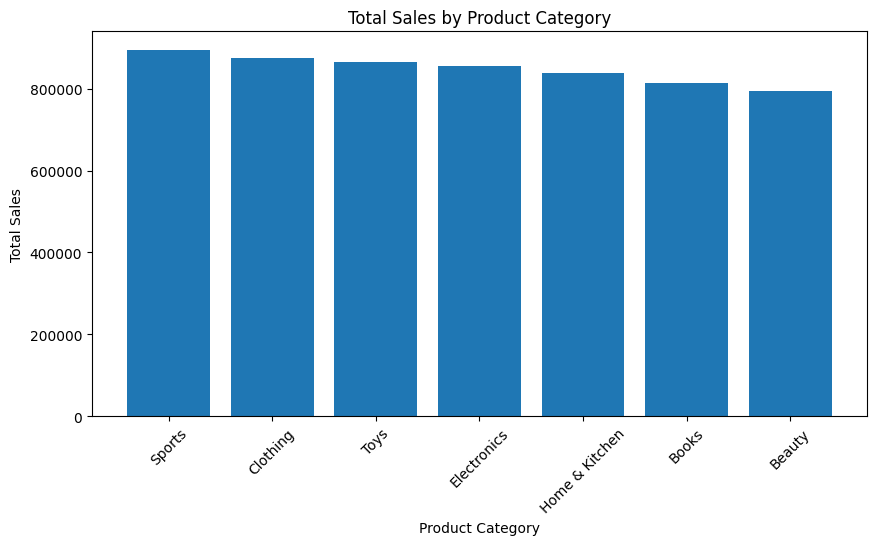

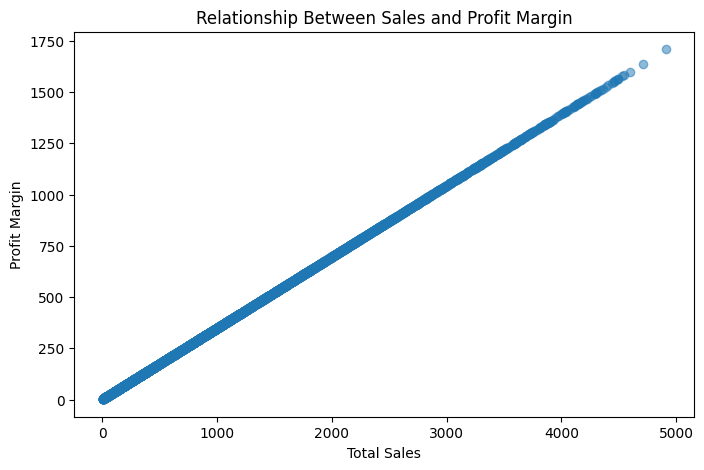


Top 10 Customers by Sales:
Customer Name
Jennifer Wright         6304.86
Anthony Johnson         5618.30
Christine Robinson      5576.58
Michael Clark           5368.75
Michael Smith           5232.61
Stephanie Garcia        5219.76
Christopher Smith       5144.21
Brandy Smith            5062.35
Christopher Robinson    4946.68
Dr. James Wood PhD      4911.92
Name: Total Sales, dtype: float64


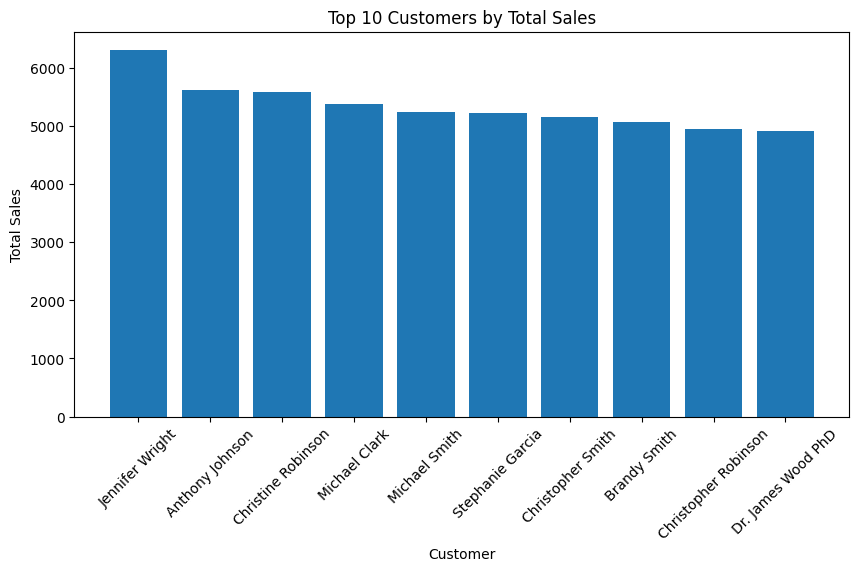


Customer-Level Dataset:
                            Customer ID  Total_Sales  Total_Profit  \
0  00199efa-f77b-439f-b061-9132e01d8a11      1597.28        555.78   
1  002353f2-a753-407c-bfbc-01e741ebfd13      2343.07        815.28   
2  00412af2-4904-4a21-b72d-7e82f94df7ba      2030.75        706.61   
3  0046530b-cdfa-4eef-868c-0ab173b72c39      1258.02        437.73   
4  004d41f0-66f9-4fab-8159-a02199ecda80      1478.54        514.46   

   Total_Quantity  Average_Discount  Average_Unit_Price  Purchase_Frequency  
0               4              9.76              442.51                   1  
1               9              2.72              267.62                   1  
2               7             23.96              381.52                   1  
3               4              1.80              320.27                   1  
4               5             12.51              337.99                   1  

Customer Dataset Shape:
(4999, 7)

Features Used for Clustering:
['Total_Sales', 'Tot

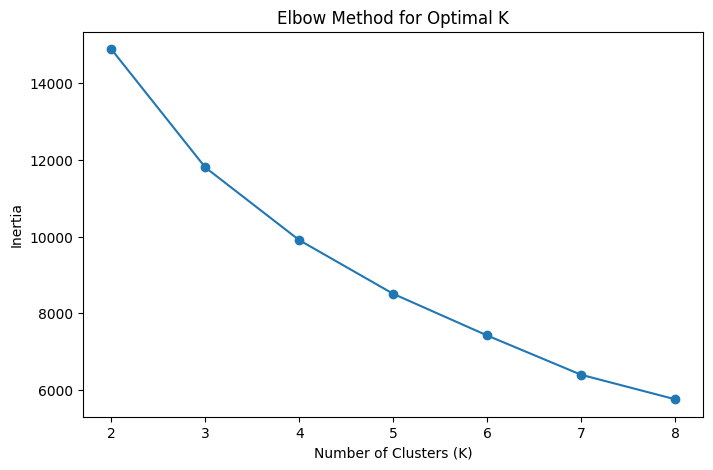


Silhouette Scores:
   Number of Clusters  Silhouette Score
0                   2          0.354175
1                   3          0.285536
2                   4          0.274398
3                   5          0.269512
4                   6          0.276023
5                   7          0.279971
6                   8          0.281484


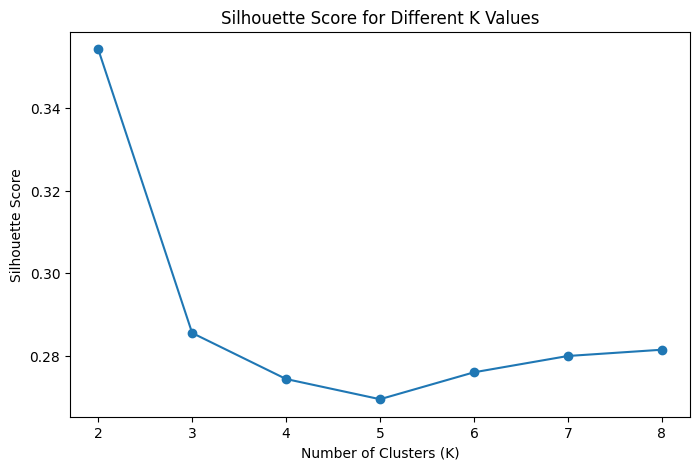


Customer Data with Cluster Labels:
                            Customer ID  Total_Sales  Total_Profit  \
0  00199efa-f77b-439f-b061-9132e01d8a11      1597.28        555.78   
1  002353f2-a753-407c-bfbc-01e741ebfd13      2343.07        815.28   
2  00412af2-4904-4a21-b72d-7e82f94df7ba      2030.75        706.61   
3  0046530b-cdfa-4eef-868c-0ab173b72c39      1258.02        437.73   
4  004d41f0-66f9-4fab-8159-a02199ecda80      1478.54        514.46   

   Total_Quantity  Average_Discount  Average_Unit_Price  Purchase_Frequency  \
0               4              9.76              442.51                   1   
1               9              2.72              267.62                   1   
2               7             23.96              381.52                   1   
3               4              1.80              320.27                   1   
4               5             12.51              337.99                   1   

   Cluster  
0        0  
1        0  
2        0  
3        1  
4  

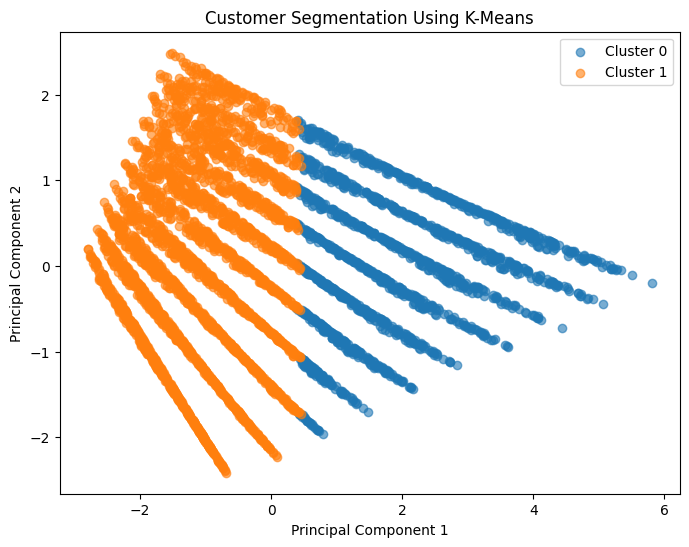


FINAL CLUSTER SUMMARY

Cluster 0
Total_Sales           2302.20
Total_Profit           801.06
Total_Quantity           7.56
Average_Discount        14.21
Average_Unit_Price     365.24
Purchase_Frequency       1.00
dtype: float64

Cluster 1
Total_Sales           567.79
Total_Profit          197.57
Total_Quantity          4.38
Average_Discount       15.28
Average_Unit_Price    194.06
Purchase_Frequency      1.00
dtype: float64


In [2]:
# ============================================================
# AMAZON SALES ANALYSIS AND CUSTOMER SEGMENTATION USING K-MEANS
# ============================================================


# ---------------------------
# 1. IMPORT LIBRARIES
# ---------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# ---------------------------
# 2. LOAD DATA
# ---------------------------

df = pd.read_csv("amazon_sales_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()


# ---------------------------
# 3. DATA UNDERSTANDING
# ---------------------------

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())


# ---------------------------
# 4. DATA CLEANING
# ---------------------------

# Convert Order Date into datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Check missing values
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Drop rows with missing Product Name
df = df.dropna(subset=["Product Name"])

# Remove duplicate rows if any
df = df.drop_duplicates()

print("\nDataset Shape After Cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================


# ---------------------------
# 5. SALES AND PROFIT DISTRIBUTION
# ---------------------------

plt.figure(figsize=(8, 5))
plt.hist(df["Total Sales"], bins=30, edgecolor="black")
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(df["Profit Margin"], bins=30, edgecolor="black")
plt.title("Distribution of Profit Margin")
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")
plt.show()


# ---------------------------
# 6. TOTAL SALES BY REGION
# ---------------------------

region_sales = (
    df.groupby("Region")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTotal Sales by Region:")
print(region_sales)

plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# ---------------------------
# 7. TOTAL PROFIT BY REGION
# ---------------------------

region_profit = (
    df.groupby("Region")["Profit Margin"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(region_profit.index, region_profit.values)
plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin")
plt.xticks(rotation=45)
plt.show()


# ---------------------------
# 8. SALES BY PRODUCT CATEGORY
# ---------------------------

category_sales = (
    df.groupby("Product Category")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTotal Sales by Product Category:")
print(category_sales)

plt.figure(figsize=(10, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# ---------------------------
# 9. SALES VS PROFIT RELATIONSHIP
# ---------------------------

plt.figure(figsize=(8, 5))
plt.scatter(df["Total Sales"], df["Profit Margin"], alpha=0.5)
plt.title("Relationship Between Sales and Profit Margin")
plt.xlabel("Total Sales")
plt.ylabel("Profit Margin")
plt.show()


# ---------------------------
# 10. TOP 10 CUSTOMERS BY SALES
# ---------------------------

top_customers = (
    df.groupby("Customer Name")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Customers by Sales:")
print(top_customers)

plt.figure(figsize=(10, 5))
plt.bar(top_customers.index, top_customers.values)
plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# CUSTOMER SEGMENTATION USING K-MEANS
# ============================================================


# ---------------------------
# 11. CREATE CUSTOMER-LEVEL DATASET
# ---------------------------

customer_data = (
    df.groupby("Customer ID")
    .agg(
        Total_Sales=("Total Sales", "sum"),
        Total_Profit=("Profit Margin", "sum"),
        Total_Quantity=("Quantity Sold", "sum"),
        Average_Discount=("Discount (%)", "mean"),
        Average_Unit_Price=("Unit Price", "mean"),
        Purchase_Frequency=("Order ID", "count")
    )
    .reset_index()
)

print("\nCustomer-Level Dataset:")
print(customer_data.head())

print("\nCustomer Dataset Shape:")
print(customer_data.shape)


# ---------------------------
# 12. SELECT FEATURES FOR CLUSTERING
# ---------------------------

features = [
    "Total_Sales",
    "Total_Profit",
    "Total_Quantity",
    "Average_Discount",
    "Average_Unit_Price",
    "Purchase_Frequency"
]

X = customer_data[features]

print("\nFeatures Used for Clustering:")
print(features)


# ---------------------------
# 13. FEATURE SCALING
# ---------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data Shape:")
print(X_scaled.shape)


# ============================================================
# FINDING OPTIMAL NUMBER OF CLUSTERS
# ============================================================


# ---------------------------
# 14. ELBOW METHOD
# ---------------------------

inertia = []

k_values = range(2, 9)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()


# ---------------------------
# 15. SILHOUETTE SCORE
# ---------------------------

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)


silhouette_results = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Silhouette Score": silhouette_scores
})

print("\nSilhouette Scores:")
print(silhouette_results)


plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()


# ============================================================
# FINAL K-MEANS MODEL
# ============================================================


# ---------------------------
# 16. APPLY K-MEANS
# ---------------------------

# Based on the Elbow Method and Silhouette Score,
# select the appropriate number of clusters.

optimal_k = 2


kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans_final.fit_predict(
    X_scaled
)


print("\nCustomer Data with Cluster Labels:")
print(customer_data.head())


# ---------------------------
# 17. NUMBER OF CUSTOMERS IN EACH CLUSTER
# ---------------------------

cluster_count = (
    customer_data["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nNumber of Customers in Each Cluster:")
print(cluster_count)


# ============================================================
# CLUSTER ANALYSIS
# ============================================================


# ---------------------------
# 18. CLUSTER PROFILE
# ---------------------------

cluster_summary = (
    customer_data
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

print("\nCluster Summary:")
print(cluster_summary)


# ---------------------------
# 19. TOTAL SALES CONTRIBUTION BY CLUSTER
# ---------------------------

cluster_sales = (
    customer_data
    .groupby("Cluster")["Total_Sales"]
    .sum()
)

cluster_sales_percentage = (
    cluster_sales / cluster_sales.sum() * 100
).round(2)


print("\nSales Contribution by Cluster (%):")
print(cluster_sales_percentage)


# ---------------------------
# 20. TOTAL PROFIT CONTRIBUTION BY CLUSTER
# ---------------------------

cluster_profit = (
    customer_data
    .groupby("Cluster")["Total_Profit"]
    .sum()
)

cluster_profit_percentage = (
    cluster_profit / cluster_profit.sum() * 100
).round(2)


print("\nProfit Contribution by Cluster (%):")
print(cluster_profit_percentage)


# ============================================================
# PCA FOR CLUSTER VISUALIZATION
# ============================================================


# ---------------------------
# 21. REDUCE DIMENSIONS TO 2
# ---------------------------

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)


# Add PCA components to dataset

customer_data["PCA1"] = X_pca[:, 0]

customer_data["PCA2"] = X_pca[:, 1]


# ---------------------------
# 22. VISUALIZE CLUSTERS
# ---------------------------

plt.figure(figsize=(8, 6))

for cluster in sorted(customer_data["Cluster"].unique()):

    cluster_data = customer_data[
        customer_data["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )


plt.title("Customer Segmentation Using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()


# ============================================================
# FINAL CLUSTER INTERPRETATION
# ============================================================


# ---------------------------
# 23. COMPARE CLUSTERS
# ---------------------------

print("\nFINAL CLUSTER SUMMARY")

for cluster in sorted(customer_data["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    print(
        customer_data[
            customer_data["Cluster"] == cluster
        ][features]
        .mean()
        .round(2)
    )


# ============================================================
# END OF ANALYSIS
# ============================================================